In [104]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scanpy as sc
import anndata as ad
import scipy as sp
import pandas as pd
import pickle
import time
import hydra

from typing import Optional, Callable
from omegaconf import DictConfig
from tqdm.notebook import tqdm
from scFM_density_estimation.models import *
from sklearn.model_selection import train_test_split

# Model 

In [105]:
# Prepare the dataset
def prepare_dataset(n, N, cond_dim, locs):
    C = np.random.randint(low=0, high=cond_dim, size=(N))
    X = np.concatenate([np.random.normal(loc=locs[c], scale=1, size=(1, n)) for c in C])

    X_train, X_test, C_train, C_test = train_test_split(X, C, test_size=10_000)

    X_train = torch.tensor(X_train).to("cuda").float()
    C_train = F.one_hot(torch.tensor(C_train).long(), num_classes=cond_dim).to("cuda").float()

    X_test = torch.tensor(X_test).to("cuda").float()
    C_test = F.one_hot(torch.tensor(C_test).long(), num_classes=cond_dim).to("cuda").float()
    return X_train, X_test, C_train, C_test

# Standard dinusoidal features of attention is all your need
def sinusoidal_time_features(t: torch.Tensor, 
                             num_freqs: int = 128, 
                             max_period: int = 10000):
    """Create sinusoidal timestep embeddings.
    :param timesteps: a 1-D Tensor of N indices, one per batch element. These may be fractional.
    :param dim: the dimension of the output.
    :param max_period: controls the minimum frequency of the embeddings.
    :return: an [N x dim] Tensor of positional embeddings.
    """
    if len(t.shape)==1:
        t = t.unsqueeze(1)
        
    half = num_freqs // 2
    freqs = torch.exp(
        -math.log(max_period)
        * torch.arange(start=0, 
                       end=half, 
                       dtype=torch.float32, 
                       device=t.device)
        / half
    )
    args = t.float() * freqs[None]
    embedding = torch.cat([torch.cos(args), torch.sin(args)], dim=-1)
    if num_freqs % 2:
        embedding = torch.cat([embedding, torch.zeros_like(embedding[:, :1])], dim=-1)
    return embedding

class Encoder(nn.Module):
    def __init__(self, cond_dim: int = 1, cond_hidden_dims: list = [],
                 cond_out_dim: int = 2, dropout: float = 0):
        super().__init__()
        layers = []
        prev_dim = cond_dim
        for dim in cond_hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, dim),
                nn.SELU(),
                nn.Dropout(dropout)
            ])
            prev_dim = dim

        layers.append(nn.Linear(prev_dim, cond_out_dim))
        self.encoder = nn.Sequential(*layers)

    def forward(self, cond):
        return self.encoder(cond)

class ConditionalFlowMatchingWithScore(L.LightningModule):
    def __init__(
        self,
        input_dim: int,
        cond_dims: list,
        hidden_dims: list,
        encoder_hidden_dims: list,
        encoder_out_dim: int,
        encoder_out_dim_cond: int, 
        use_sinusoidal_embeddings: bool, 
        sinusoidal_feature_dim: int, 
        lambda_t: Callable,
        lambda_sp_t: Callable,
        betas: list,
        lr: float = 1e-4,
        use_ot_sampler: bool = False,
        ot_method: str = "exact",
        dropout: float = 0
    ):
        super().__init__()
        self.save_hyperparameters()
        
        if use_sinusoidal_embeddings:
            self.sinusoidal_feature_dim = sinusoidal_feature_dim
        else:
            self.sinusoidal_feature_dim = 1

        self.data_encoder = Encoder(input_dim, encoder_hidden_dims, encoder_out_dim, dropout)
        self.cond_encoders = nn.ModuleList([
            Encoder(cond_dim, encoder_hidden_dims, encoder_out_dim_cond, dropout)
            for cond_dim in cond_dims
        ])
        self.vf_mlp = FlowMatchingMLP(encoder_out_dim + encoder_out_dim_cond * len(cond_dims) + self.sinusoidal_feature_dim, hidden_dims, input_dim, dropout)
        self.score_mlp = FlowMatchingMLP(encoder_out_dim + encoder_out_dim_cond * len(cond_dims) + self.sinusoidal_feature_dim, hidden_dims, input_dim, dropout)
        
        self.lambda_t = lambda_t
        self.lambda_sp_t = lambda_sp_t
        self.use_sinusoidal_embeddings = use_sinusoidal_embeddings
        self.betas = betas
        self.encoder_out_dim = encoder_out_dim
        self.encoder_out_dim_cond = encoder_out_dim_cond
        self.use_ot_sampler = use_ot_sampler
        self.cond_dims = cond_dims
        self.lr = lr

        self.vf_losses = []
        self.score_losses = []

    def forward(self, x, t, cond, use_conds=[True]):
        if t.dim() == 0 or t.size()[0] == 1:
            t = t.expand(x.shape[0]).unsqueeze(1)
        elif t.dim() == 1:
            t = t.unsqueeze(1)

        start = 0
        xc = self.data_encoder(x)
        for i, cond_dim in enumerate(self.cond_dims):
            if use_conds[i]:
                cond_enc = self.cond_encoders[i](cond[:, start:(start + cond_dim)])
            else:
                cond_enc = torch.zeros(xc.shape[0], self.encoder_out_dim_cond).to(xc.device)


            xc = torch.cat([xc, cond_enc], dim=1)
            start += cond_dim

        if self.use_sinusoidal_embeddings:
            xtc = torch.cat([xc, sinusoidal_time_features(t, self.sinusoidal_feature_dim)], dim=1)
        else:
            xtc = torch.cat([xc, t], dim=1)
        
        vf = self.vf_mlp.mlp(xtc)
        score = self.score_mlp.mlp(xtc)
        return vf, score

    def shared_step(self, x1, cond, step):
        device = x1.device

        x0 = torch.randn_like(x1).to(device)
        t = torch.rand(x1.shape[0]).unsqueeze(1).to(device)

        xt = t * x1 + self.lambda_t(t) * x0
        ut = x1 + self.lambda_sp_t(t) / self.lambda_t(t) * x0
        c_t = self.lambda_t(t) ** 2 - self.lambda_sp_t(t) * t

        use_conds = (np.random.uniform(size=len(self.betas)) >= np.array(self.betas))
        pred_ut, pred_score = self(xt, t, cond, use_conds)
        
        vf_loss = F.mse_loss(pred_ut, ut)
        score_loss = F.mse_loss(c_t * pred_score, t * ut - xt)

        if step % 100 == 0:
            self.vf_losses.append(vf_loss.item())
            self.score_losses.append(score_loss.item())

        return vf_loss + score_loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)

def train(batch_size, n_steps, model, optimizer, X, C):
    for k in tqdm(range(n_steps)):
        optimizer.zero_grad()
    
        indices = np.random.choice(range(X.shape[0]), size=batch_size, replace=False)
        loss = model.shared_step(X[indices], C[indices], k)
        
        loss.backward()
        optimizer.step()
    return model

# Simulation

In [157]:
class NODEWrapper_with_trace_div(torch.nn.Module):
    def __init__(self, model, cond, is_uncond=False):
        super().__init__()
        self.model = model
        self.cond = cond
        self.div_fn, self.eps_fn = div_fn_hutch_trace, torch.randn_like
        self.is_uncond = is_uncond

    def forward(self, t, x, *args, **kwargs):
        x = x[..., :-1]
        
        def vecfield(y):
            vf, _ = self.model(y.unsqueeze(0), t, self.cond[:1])
            return vf.squeeze()

        div = torch.vmap(self.div_fn(vecfield))(x, self.eps_fn(x))
        if self.is_uncond:
            dx, _ = self.model(x, t, self.cond, use_conds=[False])
        else:
            dx, _ = self.model(x, t, self.cond)
            
        return torch.cat([dx, div[:, None]], dim=-1)

class NODEWrapper_with_ratio_tvf_rl(torch.nn.Module):
    def __init__(self, model, control, condition, point, f_uncond=False):
        super().__init__()
        self.model = model
        self.cond_v = control
        self.cond_u = condition
        self.cond_f = point
        self.f_uncond = f_uncond 
        self.div_fn, self.eps_fn = div_fn_hutch_trace, torch.randn_like

    def forward(self, t, x, *args, **kwargs):
        x = x[..., :-1]
        
        def vecfield(y):
            ut, _ = self.model(y.unsqueeze(0), t, self.cond_u[:1])
            vt, _ = self.model(y.unsqueeze(0), t, self.cond_v[:1])
            return vt.squeeze() - ut.squeeze()
            
        div = torch.vmap(self.div_fn(vecfield))(x, self.eps_fn(x))
        
        ut, score_u = self.model(x, t, self.cond_u)
        vt, score_v = self.model(x, t, self.cond_v)
        if self.f_uncond:
            ft, _ = self.model(x, t, self.cond_f, use_conds=[False])
        else:
            ft, _ = self.model(x, t, self.cond_f)
        
        correction_term_u = torch.linalg.vecdot(ft - ut, score_u)
        correction_term_v = torch.linalg.vecdot(vt - ft, score_v)
        dr = div + correction_term_u + correction_term_v
        
        return torch.cat([ft, dr[:, None]], dim=-1)

def evaluate_model(model, data_samples, cond, cond_dim, condition, control, locs):
    # Initialize device and time 
    device = data_samples.device
    
    start_true = time.time()

    log_condition_true = -0.5 * ((data_samples.cpu().numpy() - np.array(locs[np.argmax(condition)])) ** 2).sum(axis=1) - 0.5 * data_samples.shape[1] * np.log(2 * np.pi)
    log_control_true = -0.5 * ((data_samples.cpu().numpy() - np.array(locs[np.argmax(control)])) ** 2).sum(axis=1) - 0.5 * data_samples.shape[1] * np.log(2 * np.pi)
    log_ratio_true = log_condition_true - log_control_true
    
    time_true = time.time() - start_true
    
    start_hat = time.time()

    # naive evaluation
    node = NeuralODE(
        NODEWrapper_with_trace_div(model, 
                                   torch.tensor(condition).float().expand(data_samples.shape[0], cond_dim).to(device),
                                   is_uncond=False),
        solver="dopri5", sensitivity="adjoint", atol=1e-4, rtol=1e-4
    )

    with torch.no_grad():
        traj = node.trajectory(
            torch.cat([data_samples, torch.zeros(data_samples.shape[0], 1).to(device)], dim=-1),
            t_span=torch.linspace(1, 0, 100).to(device)
        )
    z0, div = traj[-1][:, :-1], traj[-1][:, -1]
    log_condition_hat = (-0.5 * (z0 ** 2).sum(dim=1) - 0.5 * z0.shape[1] * np.log(2 * np.pi) + div).cpu().numpy()
    
    node = NeuralODE(
        NODEWrapper_with_trace_div(model,
                                   torch.tensor(control).float().expand(data_samples.shape[0], cond_dim).to(device),
                                   is_uncond=False),
        solver="dopri5", sensitivity="adjoint", atol=1e-4, rtol=1e-4
    )
    
    with torch.no_grad():
        traj = node.trajectory(
            torch.cat([data_samples, torch.zeros(data_samples.shape[0], 1).to(device)], dim=-1),
            t_span=torch.linspace(1, 0, 100).to(device)
        )
    z0, div = traj[-1][:, :-1], traj[-1][:, -1]
    log_control_hat = (-0.5 * (z0 ** 2).sum(dim=1) - 0.5 * z0.shape[1] * np.log(2 * np.pi) + div).cpu().numpy()
    
    log_ratio_hat = log_condition_hat - log_control_hat
    
    time_hat = time.time() - start_hat

    start_hat_v2 = time.time()

    # correction term - its own field
    node = NeuralODE(
        NODEWrapper_with_ratio_tvf_rl(model, 
                                      control=torch.tensor(control).float().expand(data_samples.shape[0], cond_dim).to(device),
                                      condition=torch.tensor(condition).float().expand(data_samples.shape[0], cond_dim).to(device), 
                                      point=cond, 
                                      f_uncond=True),
        solver="dopri5", sensitivity="adjoint", atol=1e-4, rtol=1e-4
    )
    
    with torch.no_grad():
        traj = node.trajectory(
            torch.cat([data_samples, torch.zeros(data_samples.shape[0], 1).to(device)], dim=-1),
            t_span=torch.linspace(1, 0, 100).to(device)
        )
    z0, ratio = traj[-1][:, :-1], traj[-1][:, -1]
    log_ratio_hat_v2 = -ratio.cpu().numpy()
    
    time_hat_v2 = time.time() - start_hat_v2
    
    return [log_ratio_true, log_ratio_hat, log_ratio_hat_v2], [time_true, time_hat, time_hat_v2]

# Data and training 

In [173]:
model.device

device(type='cuda', index=0)

In [174]:
np.random.seed(42)

n = 30
N = 100_000 
cond_dim = 2
batch_size = 512
n_steps = 200_000
control = np.array([1, 0])
condition = np.array([0, 1])
locs = [[0 for _ in range(n)]] + [[2 for _ in range(n)]]
sigma = 0.25
sigma_min = 0

names = ["true", "naive", "ct own rl"]

X_train, X_test, C_train, C_test = prepare_dataset(n, N, cond_dim, locs)

mask_condition = np.all(C_test.cpu().numpy() == condition, axis=1)
mask_control = np.all(C_test.cpu().numpy() == control, axis=1)
mask_both = mask_condition | mask_control 

lambda_t = lambda t: torch.sqrt((1 - (1 - sigma_min) * t) ** 2 + sigma * t * (1 - t))
lambda_sp_t = lambda t: (sigma * (1 - 2 * t) - 2 * (1 - sigma_min) * (1 - (1 - sigma_min) * t)) / 2

model = ConditionalFlowMatchingWithScore(
    input_dim=n,
    cond_dims=[cond_dim],
    hidden_dims=[1024, 1024, 1024],
    encoder_hidden_dims=[256],
    encoder_out_dim=256,
    encoder_out_dim_cond=50,
    use_sinusoidal_embeddings=True,
    sinusoidal_feature_dim=50,
    lambda_t=lambda_t,
    lambda_sp_t=lambda_sp_t,
    betas=[0.5], 
    lr=1e-4
).to("cuda")
optimizer = model.configure_optimizers()

In [175]:
model = train(batch_size, n_steps, model, optimizer, X_train, C_train)

  0%|          | 0/200000 [00:00<?, ?it/s]

## Check results 

In [167]:
log_ratios, times = evaluate_model(model, X_test, C_test, cond_dim, condition, control, locs)

In [168]:
np.mean(np.abs(log_ratios[0] - log_ratios[1]))

np.float64(45.46070319853466)

In [169]:
np.mean(np.abs(log_ratios[0] - log_ratios[2]))

np.float64(39.755147130257484)

In [170]:
np.mean((log_ratios[0] - log_ratios[1])**2)

np.float64(2166.477010319106)

In [171]:
np.mean((log_ratios[0] - log_ratios[2])**2)

np.float64(1805.7990558399945)

## Chec data generation

In [141]:
import scanpy as sc

In [142]:
x0 = torch.randn(500, n).to("cuda")

In [143]:
# Generate controls 
node = NeuralODE(
    NODEWrapper_with_trace_div(model, torch.tensor(control).float().expand(x0.shape[0], cond_dim).to("cuda")),
    solver="dopri5", sensitivity="adjoint", atol=1e-4, rtol=1e-4
)

with torch.no_grad():
    traj = node.trajectory(
        torch.cat([x0, torch.zeros(x0.shape[0], 1).to("cuda")], dim=-1),
        t_span=torch.linspace(0, 1, 100).to("cuda")
    )
z_control, _ = traj[-1][:, :-1], traj[-1][:, -1]

In [144]:
# Generate conditions 
node = NeuralODE(
    NODEWrapper_with_trace_div(model, torch.tensor(condition).float().expand(x0.shape[0], cond_dim).to("cuda")),
    solver="dopri5", sensitivity="adjoint", atol=1e-4, rtol=1e-4
)

with torch.no_grad():
    traj = node.trajectory(
        torch.cat([x0, torch.zeros(x0.shape[0], 1).to("cuda")], dim=-1),
        t_span=torch.linspace(0, 1, 100).to("cuda")
    )
z_condition, _ = traj[-1][:, :-1], traj[-1][:, -1]

In [145]:
z_control = z_control.detach().cpu()
z_condition = z_condition.detach().cpu()

In [146]:
adata = sc.AnnData(X=np.concatenate([X_test.cpu().numpy(), 
                                     z_control, 
                                     z_condition], axis=0))

obs = pd.DataFrame({"dataset_type": ["real" for _ in range(X_test.shape[0])] + \
                    ["generated_ctr" for _ in range(z_control.shape[0])] + \
                    ["generated_cond" for _ in range(z_control.shape[0])]})

In [147]:
adata.obs = obs

In [148]:
sc.pp.neighbors(adata)
sc.tl.umap(adata)

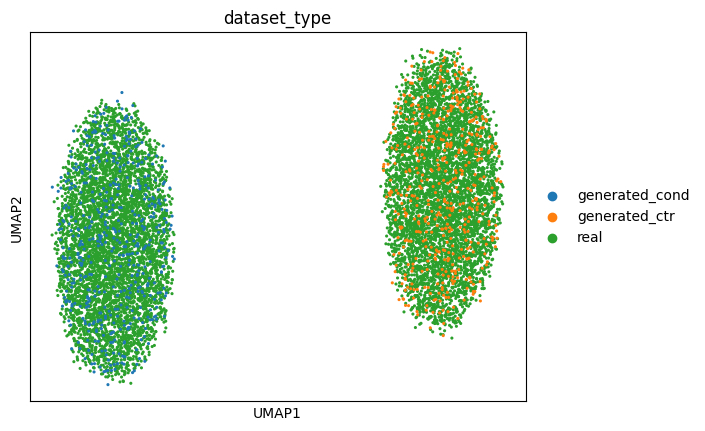

In [149]:
sc.pl.umap(adata, color = "dataset_type", s=20)

In [158]:
# Generate controls 
node = NeuralODE(
    NODEWrapper_with_trace_div(model, 
                               torch.tensor(control).float().expand(x0.shape[0], cond_dim).to("cuda"), 
                               is_uncond=True),
    solver="dopri5", sensitivity="adjoint", atol=1e-4, rtol=1e-4)


with torch.no_grad():
    traj = node.trajectory(
        torch.cat([x0, torch.zeros(x0.shape[0], 1).to("cuda")], dim=-1),
        t_span=torch.linspace(0, 1, 100).to("cuda"),
    )
    
z_uncond, _ = traj[-1][:, :-1], traj[-1][:, -1]

In [161]:
z_uncond = z_uncond.detach().cpu()

In [162]:
adata = sc.AnnData(X=np.concatenate([X_test.cpu().numpy(), 
                                     z_uncond], axis=0))

obs = pd.DataFrame({"dataset_type": ["real" for _ in range(X_test.shape[0])] + \
                    ["generated_ctr" for _ in range(z_uncond.shape[0])]})

In [163]:
adata.obs = obs

In [164]:
sc.pp.neighbors(adata)
sc.tl.umap(adata)

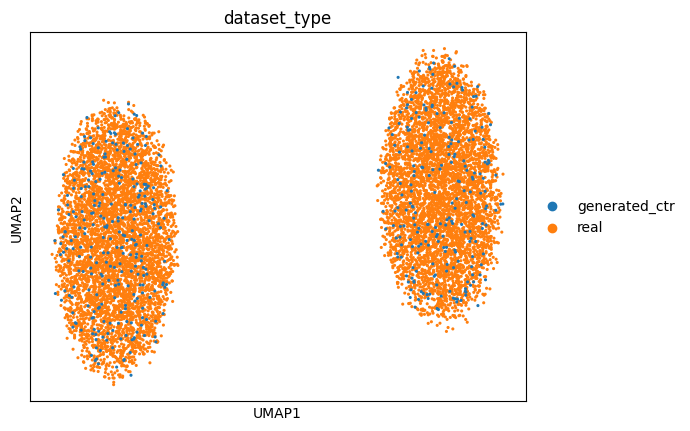

In [165]:
sc.pl.umap(adata, color = "dataset_type", s=20)